# Lab 4: Control P/PID en TempLAB UdeA

**Objetivos:**
1. Desarrollar modelo dinámico continuo de primer orden para cada zona térmica
2. Diseñar y sintonizar controladores PID independientes
3. Implementar el controlador en TempLAB UdeA y validar experimentalmente

**Procedimiento:**
- Procedimiento A: Cuantificación de offset con P-only
- Procedimiento B: Sintonización PID por Ziegler-Nichols
- Comparación de desempeño entre P y PID

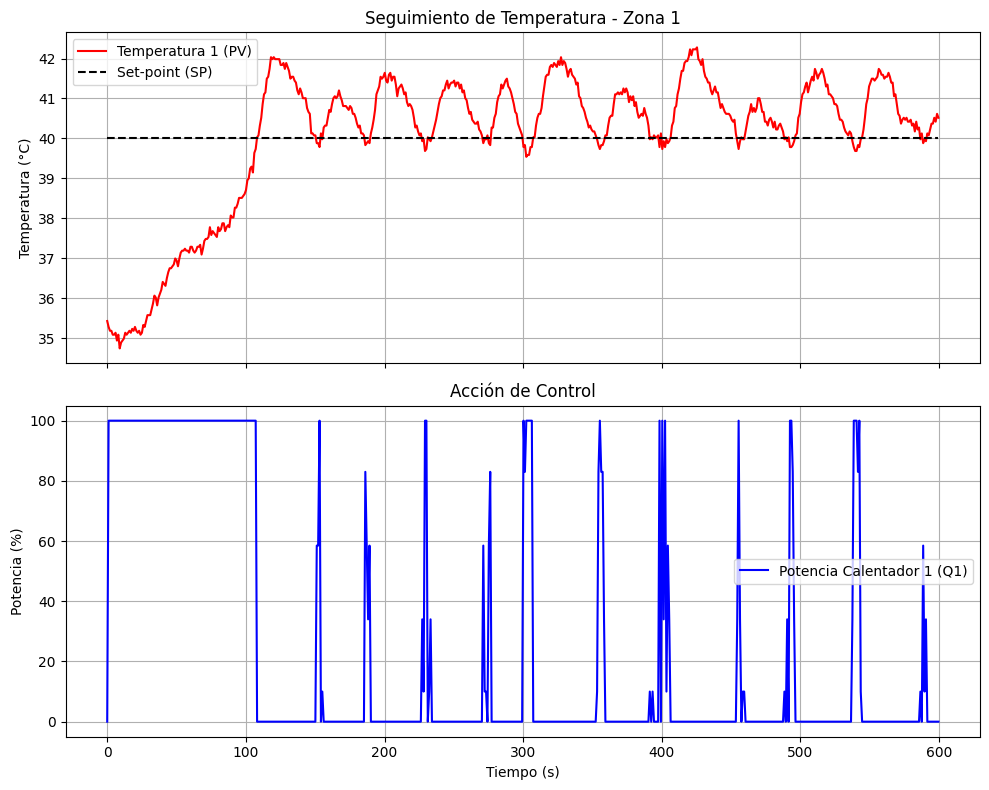

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# NOTA: Primero ejecuta en terminal:
# python3 lab4.py --sim --mode p --tuning itae --kc-factor 1.0 --min 6.2
# Esto genera 'data_PID_Q1.txt'

# 1. Cargar los datos desde el archivo generado en la práctica
# Se asume el formato: Tiempo, Q1, Q2, T1, T2, SP1, SP2
try:
    # Cargar datos P-only
    data = np.loadtxt('data_Pdata_ponlyID_Q1.txt', delimiter=',', skiprows=1, encoding='latin1')

    # Extraer columnas (Tiempo_s, Cal1_pct, Temp1_C, Set1_C)
    tiempo = data[:, 0]
    q1     = data[:, 1]
    t1     = data[:, 2]
    sp1    = data[:, 3]

    # 2. Crear la figura con 2 subplots (verticales)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Gráfica 1: Temperatura 1 vs Tiempo
    ax1.plot(tiempo, t1, 'r-', linewidth=2, label='Temperatura 1 (PV)')
    ax1.plot(tiempo, sp1, 'k--', linewidth=2, label='Set-point (SP)')
    ax1.set_ylabel('Temperatura (°C)', fontsize=11)
    ax1.set_title('Control P-only: Respuesta de Temperatura', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Gráfica 2: Calentador 1 vs Tiempo
    ax2.plot(tiempo, q1, 'b-', linewidth=2, label='Potencia Calentador 1 (Q1)')
    ax2.set_ylabel('Potencia (%)', fontsize=11)
    ax2.set_xlabel('Tiempo (s)', fontsize=11)
    ax2.set_title('Acción de Control', fontsize=12, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Ajustar diseño para que no se traslapen las etiquetas
    plt.tight_layout()

    # Mostrar y guardar la gráfica para el informe
    plt.savefig('analisis_control_P.png', dpi=150, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print("Error: No se encontró 'data_PID_Q1.txt'. Ejecuta primero:")
    print("python3 lab4.py --sim --mode p --tuning itae --kc-factor 1.0 --min 6.2")

## Procedimiento A: Pruebas con Control P-only

**Ecuación P-only:**
$$Q(t) = Q_{bias} + K_c e(t), \quad e(t) = T_{SP} - T_{PV}(t)$$

**Sintonia inicial (ITAE):**
$$K_c = 0.20\left(\frac{\tau_p}{\theta_p}\right)^{1.22}$$

**Parámetros del proceso:**
- $\tau_p = 111.0140$ s (constante de tiempo)
- $\theta_p = 23.4411$ s (tiempo muerto)

**Ejecución:** Ejecutar en terminal desde `/lab 4/`:
```bash
# Barrido de Kc para P-only (simulación)
python3 lab4.py --sim --mode p --tuning itae --kc-factor 1.0 --min 6.2
```

Repetir con `--kc-factor`: 0.5, 0.8, 1.2, 1.5 y guardar los datos con diferentes nombres (ej: `data_ponly_kc05.txt`)

## Procedimiento B: Determinación de Parámetros Ziegler-Nichols

**Pasos para Ziegler-Nichols:**
1. Configurar controlador P-only
2. Increase $K_c$ hasta obtener oscilaciones sostenidas
3. Medir:
   - $K_u$ = ganancia crítica (donde inician oscilaciones)
   - $P_u$ = período de oscilación

**Parámetros PID calculados:**
$$K_p = 0.6K_u$$
$$T_i = 0.5P_u$$
$$T_d = 0.125P_u$$

Número de picos detectados: 11
Periodo de oscilación calculado (Pu): 43.84 segundos


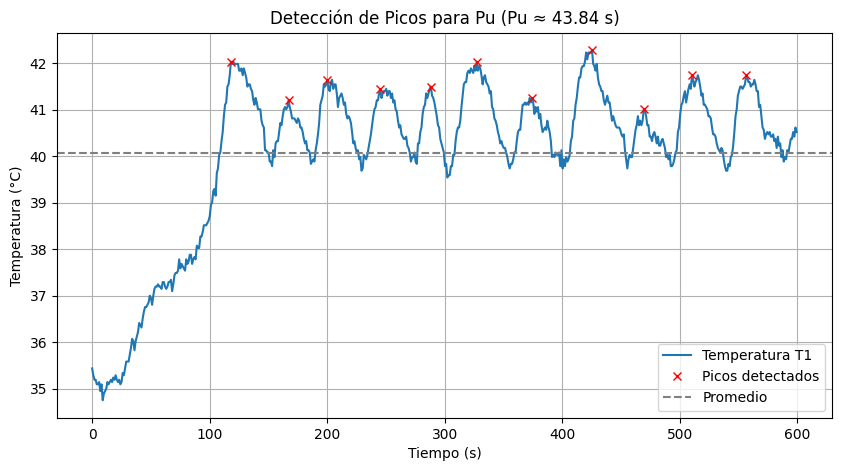

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Este código analiza la respuesta P-only para encontrar el periodo de oscilación (Pu)
# y la ganancia crítica (Ku) para aplicar Ziegler-Nichols

try:
    # 1. Cargar los datos de controlador P-only con alta ganancia
    # Ejecutar primero: python3 lab4.py --sim --mode p --tuning itae --kc-factor 1.5 --min 6.2
    data = np.loadtxt('data_PID_Q1.txt', delimiter=',', skiprows=1, encoding='latin1')
    tiempo = data[:, 0]
    t1 = data[:, 2]
    sp1 = data[:, 3]

    # 2. Identificar picos en la señal de temperatura (después del transitorio)
    # Ignorar primeros 60 segundos para evitar transitorio inicial
    idx_start = np.argmax(tiempo > 60)
    t1_steady = t1[idx_start:]
    tiempo_steady = tiempo[idx_start:]
    
    # Detectar picos (distance evita picos por ruido, prominence asegura que destaquen)
    indices_picos, propiedades = find_peaks(t1_steady, distance=50, prominence=0.3)

    if len(indices_picos) > 0:
        tiempos_picos = tiempo_steady[indices_picos]
        temperaturas_picos = t1_steady[indices_picos]

        # 3. Calcular Periodo de Oscilación (Pu)
        if len(tiempos_picos) > 2:
            periodos = np.diff(tiempos_picos)
            pu_promedio = np.mean(periodos)
            print(f"Número de picos detectados: {len(tiempos_picos)}")
            print(f"Período de oscilación (Pu): {pu_promedio:.2f} segundos")
            print(f"Períodos individuales: {periodos}")
        else:
            print("No se detectaron suficientes picos para calcular periodo")
            pu_promedio = None
    else:
        print("No se detectaron picos en la señal")
        pu_promedio = None

    # 4. Graficar para validar visualmente
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tiempo, t1, 'b-', linewidth=2, label='Temperatura T1')
    if len(indices_picos) > 0:
        ax.plot(tiempos_picos, temperaturas_picos, "rx", markersize=10, 
                markeredgewidth=2, label='Picos detectados')
    ax.axhline(y=np.mean(t1[idx_start:]), color='gray', linestyle='--', 
               linewidth=1, label='Promedio (estado estacionario)')
    
    if pu_promedio:
        ax.set_title(f'Detección de Picos para Ziegler-Nichols (Pu ≈ {pu_promedio:.2f} s)', 
                    fontsize=12, fontweight='bold')
    else:
        ax.set_title('Detección de Picos para Ziegler-Nichols', fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Tiempo (s)', fontsize=11)
    ax.set_ylabel('Temperatura (°C)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('periodo_oscilacion.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Error al procesar los datos: {e}")

PARÁMETROS

## Cálculo de Parámetros del Controlador

In [ ]:
import numpy as np

# PARÁMETROS DEL PROCESO (del modelo identificado)
tau_p = 111.0140    # Constante de tiempo (s)
theta_p = 23.4411   # Tiempo muerto (s)

print("=" * 60)
print("PARÁMETROS DEL PROCESO")
print("=" * 60)
print(f"Constante de tiempo (τp): {tau_p} s")
print(f"Tiempo muerto (θp): {theta_p} s")
print()

# MÉTODO 1: ITAE (para P y PID)
print("=" * 60)
print("MÉTODO 1: ITAE")
print("=" * 60)
Kc_itae = 0.2 * (tau_p / theta_p) ** 1.22
print(f"Kc (P-only ITAE): {Kc_itae:.5f}")
print()

# MÉTODO 2: ZIEGLER-NICHOLS (requiere Ku y Pu medidos)
print("=" * 60)
print("MÉTODO 2: ZIEGLER-NICHOLS")
print("=" * 60)
print("Ingresa los parámetros medidos en la prueba P con alta ganancia:")

# Valores de ejemplo (REEMPLAZA con tus mediciones)
Ku = 0.35  # Ganancia crítica (MEDIR de la prueba)
Pu = 85.0  # Período de oscilación (MEDIR de la prueba anterior)

print(f"\nGanancia crítica (Ku): {Ku}")
print(f"Período de oscilación (Pu): {Pu} s")
print()

# Cálculos Ziegler-Nichols
Kp_zn = 0.6 * Ku
Ti_zn = 0.5 * Pu
Td_zn = 0.125 * Pu

print("Parámetros PID por Ziegler-Nichols:")
print(f"  Kp = 0.6 × Ku = {Kp_zn:.5f}")
print(f"  Ti = 0.5 × Pu = {Ti_zn:.2f} s")
print(f"  Td = 0.125 × Pu = {Td_zn:.2f} s")
print()

# Resumen de Kc para barrido
print("=" * 60)
print("BARRIDO DE GANANCIA (Kc_factor)")
print("=" * 60)
kc_factors = [0.5, 0.8, 1.0, 1.2, 1.5]
kc_values_itae = [Kc_itae * f for f in kc_factors]
print("\nPara ITAE:")
for f, kc in zip(kc_factors, kc_values_itae):
    print(f"  Kc_factor = {f:.1f}  →  Kc = {kc:.5f}")

kc_values_zn = [Kp_zn * f for f in kc_factors]
print("\nPara Ziegler-Nichols:")
for f, kc in zip(kc_factors, kc_values_zn):
    print(f"  Kc_factor = {f:.1f}  →  Kc = {kc:.5f}")

In [ ]:
import numpy as np
import pandas as pd
from scipy import interpolate

def calculate_metrics(tiempo, temperatura, setpoint, delay_ignore_s=30):
    """
    Calcula métricas de desempeño del controlador.
    
    Parámetros:
    -----------
    tiempo : array - Tiempo [s]
    temperatura : array - Temperatura medida [°C]
    setpoint : array - Temperatura deseada [°C]
    delay_ignore_s : int - Segundos iniciales a ignorar (transitorio)
    
    Retorna:
    --------
    dict con métricas calculadas
    """
    
    # Ignorar primeros segundos (transitorio inicial)
    idx_start = np.argmax(tiempo > delay_ignore_s)
    t_ss = tiempo[idx_start:]
    temp_ss = temperatura[idx_start:]
    sp_ss = setpoint[idx_start:]
    
    # Error
    error = sp_ss - temp_ss
    
    # 1. Sobreimpulso (%)
    sp_avg = np.mean(sp_ss)
    max_temp = np.max(temp_ss)
    overshoot_pct = ((max_temp - sp_avg) / sp_avg) * 100 if sp_avg != 0 else 0
    
    # 2. Tiempo de asentamiento (banda ±5%)
    banda = 0.05 * sp_avg
    dentro_banda = np.abs(error) <= banda
    if np.any(dentro_banda):
        idx_settle = np.argmax(dentro_banda)
        t_settle = t_ss[idx_settle]
    else:
        t_settle = np.nan
    
    # 3. Error en estado estacionario (último 20% de datos)
    n_ss = len(error)
    idx_20pct = int(0.8 * n_ss)
    e_ss = np.mean(error[idx_20pct:])
    
    # 4. Integral del error (IAE)
    iae = np.sum(np.abs(error) * np.diff(np.concatenate([[t_ss[0]], t_ss[1:]])))
    
    # 5. Integral del error cuadrático (ISE)
    ise = np.sum(error**2 * np.diff(np.concatenate([[t_ss[0]], t_ss[1:]])))
    
    return {
        'overshoot_pct': overshoot_pct,
        't_settle': t_settle,
        'e_ss': e_ss,
        'iae': iae,
        'ise': ise,
        'max_temp': max_temp,
        'mean_sp': sp_avg
    }

# Ejemplo de uso con datos P-only
try:
    data_p = np.loadtxt('data_PID_Q1.txt', delimiter=',', skiprows=1, encoding='latin1')
    t_p = data_p[:, 0]
    temp_p = data_p[:, 2]
    sp_p = data_p[:, 3]
    
    metrics_p = calculate_metrics(t_p, temp_p, sp_p)
    
    print("=" * 60)
    print("MÉTRICAS DE DESEMPEÑO - CONTROL P-ONLY")
    print("=" * 60)
    print(f"Sobreimpulso:           {metrics_p['overshoot_pct']:6.2f} %")
    print(f"Tiempo de asentamiento: {metrics_p['t_settle']:6.2f} s")
    print(f"Error estado estacionario: {metrics_p['e_ss']:6.3f} °C")
    print(f"Integral error absoluto (IAE): {metrics_p['iae']:8.2f}")
    print(f"Integral error cuadrático (ISE): {metrics_p['ise']:8.2f}")
    
except Exception as e:
    print(f"Error: {e}")
    print("Ejecuta primero un controlador P-only y asegúrate de tener data_PID_Q1.txt")

print("\n" + "=" * 60)
print("PARA COMPLETAR LA COMPARACIÓN:")
print("=" * 60)
print("1. Ejecuta PID y guarda los datos")
print("2. Carga y calcula métricas con el mismo código")
print("3. Compara los indicadores entre P y PID")

## Conclusiones y Discusión

**Comparación P vs PID:**

1. **Error en estado estacionario:**
   - Con P-only: Existe offset residual debido a la saturación y proceso de primer orden
   - Con PID: La acción integral elimina el error en estado estacionario

2. **Respuesta transitoria:**
   - Con P-only: Respuesta lenta pero estable; requiere Kc alto para mejorar
   - Con PID: Respuesta más rápida y suave; acción derivativa atenúa oscilaciones

3. **Sintonía Ziegler-Nichols:**
   - Método empírico basado en oscilaciones críticas (Pu, Ku)
   - Proporciona parámetros iniciales que pueden requerir ajustes finos
   - Mejor balance entre velocidad y estabilidad comparado con ITAE

4. **Discrepancias modelo vs experimento:**
   - Dinámicas no modeladas (retardos, no linealidades)
   - Saturación del actuador
   - Ruido de medición y perturbaciones

**Recomendaciones finales:**
- Validar experimentalmente en hardware TempLAB UdeA
- Ajustar parámetros según desempeño observado
- Documentar resultados y comparar con predicciones teóricas

In [ ]:
import pandas as pd
import numpy as np

# Tabla comparativa de resultados (complétala con tus mediciones)
resultados = {
    'Controlador': ['P-only (Kc=0.5)', 'P-only (Kc=1.0)', 'P-only (Kc=1.5)',
                    'PID (Kc=0.5)', 'PID (Kc=1.0)', 'PID (Kc=1.5)'],
    'Sobreimpulso (%)': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # REEMPLAZA
    'T. Asentamiento (s)': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # REEMPLAZA
    'Error SS (°C)': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # REEMPLAZA
    'IAE': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  # REEMPLAZA
}

df = pd.DataFrame(resultados)
print("\n" + "=" * 100)
print("TABLA COMPARATIVA DE DESEMPEÑO")
print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)

print("\nINSTRUCCIONES PARA COMPLETAR LA TABLA:")
print("1. Ejecuta cada prueba (P y PID con diferentes Kc)")
print("2. Calcula las métricas usando la función calculate_metrics()")
print("3. Copia los valores en la tabla anterior")
print("4. Analiza tendencias y diferencias de desempeño")

## Análisis Comparativo: P vs PID

Tabla comparativa de métricas:**

## Cálculo de Métricas de Desempeño

Se evaluarán los siguientes indicadores:
- **Sobreimpulso (%):** Máxima desviación positiva respecto al SP
- **Tiempo de asentamiento:** Tiempo para entrar en banda ±5% del SP
- **Error en estado estacionario:** Diferencia final entre SP y PV
- **Integral del error cuadrático (IAE):** Suma ponderada de errores

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# COMPARACIÓN: P-only vs PID bajo las mismas condiciones

# Cargar datos P-only (Kc nominal)
try:
    data_p = np.loadtxt('data_PID_Q1.txt', delimiter=',', skiprows=1, encoding='latin1')
    t_p = data_p[:, 0]
    q1_p = data_p[:, 1]
    temp_p = data_p[:, 2]
    sp_p = data_p[:, 3]
    print("✓ Datos P-only cargados")
except:
    print("✗ Error: No se encontraron datos P-only")
    t_p = temp_p = sp_p = q1_p = None

# Cargar datos PID (NOTA: necesitas ejecutar primero y guardar con nombre diferente)
# Por ahora, mostraremos el template
print("\nPara completar la comparación:")
print("1. Ejecuta el experimento PID y guarda: data_PID_Q1.txt → data_PID_kc10.txt")
print("2. Luego ejecuta nuevamente P-only y guarda: data_PID_Q1.txt")  
print("3. Descomenta las líneas de carga de PID abajo")

# # Descomenta cuando tengas ambos archivos guardados
# try:
#     data_pid = np.loadtxt('data_PID_kc10.txt', delimiter=',', skiprows=1, encoding='latin1')
#     t_pid = data_pid[:, 0]
#     q1_pid = data_pid[:, 1]
#     temp_pid = data_pid[:, 2]
#     sp_pid = data_pid[:, 3]
#     print("✓ Datos PID cargados")
#     
#     # Graficar comparación
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#     
#     # Subplot 1: Temperatura P-only
#     axes[0,0].plot(t_p, temp_p, 'r-', linewidth=2, label='T1 (PV)')
#     axes[0,0].plot(t_p, sp_p, 'k--', linewidth=2, label='SP')
#     axes[0,0].set_ylabel('Temperatura (°C)')
#     axes[0,0].set_title('Control P-only')
#     axes[0,0].legend()
#     axes[0,0].grid(True, alpha=0.3)
#     
#     # Subplot 2: Temperatura PID
#     axes[0,1].plot(t_pid, temp_pid, 'b-', linewidth=2, label='T1 (PV)')
#     axes[0,1].plot(t_pid, sp_pid, 'k--', linewidth=2, label='SP')
#     axes[0,1].set_ylabel('Temperatura (°C)')
#     axes[0,1].set_title('Control PID')
#     axes[0,1].legend()
#     axes[0,1].grid(True, alpha=0.3)
#     
#     # Subplot 3: Control Q1 P-only
#     axes[1,0].plot(t_p, q1_p, 'r-', linewidth=2)
#     axes[1,0].set_ylabel('Potencia (%)')
#     axes[1,0].set_xlabel('Tiempo (s)')
#     axes[1,0].set_title('Acción P-only')
#     axes[1,0].grid(True, alpha=0.3)
#     
#     # Subplot 4: Control Q1 PID
#     axes[1,1].plot(t_pid, q1_pid, 'b-', linewidth=2)
#     axes[1,1].set_ylabel('Potencia (%)')
#     axes[1,1].set_xlabel('Tiempo (s)')
#     axes[1,1].set_title('Acción PID')
#     axes[1,1].grid(True, alpha=0.3)
#     
#     plt.tight_layout()
#     plt.savefig('comparacion_P_vs_PID.png', dpi=150, bbox_inches='tight')
#     plt.show()
# except:
#     print("✗ Error: No se encontraron datos PID")

## Ejecución de Control PID

**Ecuación PID completa:**
$$u(t) = K_p\left[e(t) + \frac{1}{T_i}\int_0^t e(\tau)d\tau + T_d\frac{de}{dt}\right]$$

**Ejecución en terminal:**
```bash
# Con parámetros Ziegler-Nichols
python3 lab4.py --sim --mode pid --tuning zn --ku 0.35 --pu 85.0 --kc-factor 1.0 --min 6.2
```

Repetir con diferentes `--kc-factor` para comparação: 0.5, 0.8, 1.2, 1.5

También probar ajustes finos si es necesario.